# NMF Topic Model — Scotland

**Corpus:** 482 articles post-cleaning (511 raw → cleaned by removing GTCS boilerplate, ADES empty articles, and articles <200 chars)

**Sources:** gov_scot (~40%), children_in_scotland (~35%), GTCS, ADES, SERA

**Model:** NMF, k=15 (coherence peaks at k=10 but domain review favours k=15 for interpretability), max_features=2000, min_df=3

**Key findings:**
- 15 interpretable topics; child-centred and rights-based framing dominates
- 6 topics have no equivalent in England or Ireland models (UNCRC, care/Promise, Gaelic, FSM, breakfast clubs, student carers)
- Most balanced source distribution of the three countries — no single source exceeds 86% in any topic
- Government + civil society two-actor conversation (gov_scot ~40%, children_in_scotland ~35%)
- Gaelic language emerges as a topic here but Irish language is absent in Ireland — same policy area, different source selection outcomes


In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
from pathlib import Path
import logging
logging.basicConfig(level=logging.INFO)
logging.getLogger("gensim").setLevel(logging.WARNING)

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

from model_pipeline.training.s02_cleaning import run_cleaning
from model_pipeline.training.s03_spacy_processing import run_spacy_processing
from model_pipeline.training.s04_vectorisation import run_vectorisation
from model_pipeline.training.s05_nmf_training import run_nmf_training, get_top_words_per_topic
from model_pipeline.training.s06_topic_allocation import TOPIC_NAMES
from model_pipeline.training.s04_vectorisation import run_vectorisation, build_vectorizer


INFO:model_pipeline.training.s06_topic_allocation:Loaded 30 topic names from llm_topic_review.json


## 1. Load Scotland data only

In [2]:
df_sco = pd.read_csv("../../data/training/sco_training.csv")
df_sco["country"] = "sco"
df_sco["text"] = df_sco["title"].fillna("") + "\n\n" + df_sco["text"].fillna("")
df_sco["date"] = pd.to_datetime(df_sco["article_date"], errors="coerce")

print(f"Scotland corpus: {len(df_sco)} articles")
print(f"By source:\n{df_sco['source'].value_counts()}")

Scotland corpus: 511 articles
By source:
source
gov_scot                188
children_in_scotland    182
gtcs                     67
ades                     50
sera                     24
Name: count, dtype: int64


## 2. Preprocessing

In [3]:
df_sco = run_cleaning(df_sco)
df_sco = run_spacy_processing(df_sco)
print(f"After preprocessing: {df_sco.shape}")
print(f"Empty text_final: {(df_sco['text_final'].str.len() == 0).sum()}")

INFO:model_pipeline.training.s02_cleaning:Step 02 (cleaning): starting. Input shape=(511, 14)
INFO:model_pipeline.training.s02_cleaning:Dropping 29 articles with fewer than 200 chars after cleaning
INFO:model_pipeline.training.s02_cleaning:Step 02 (cleaning): complete. Output shape=(482, 15)
INFO:model_pipeline.training.s02_cleaning:Empty cleaned texts: 0
INFO:model_pipeline.training.s03_spacy_processing:Step 03 (spacy): starting. Input shape=(482, 15)
INFO:model_pipeline.training.s03_spacy_processing:Loading spaCy model: en_core_web_sm
INFO:model_pipeline.training.s03_spacy_processing:spaCy processing complete (tokens_after_spacy created).
INFO:model_pipeline.training.s03_spacy_processing:Post-spaCy junk filtering complete (tokens_final + text_final created).
INFO:model_pipeline.training.s03_spacy_processing:Empty text_final rows: 0
INFO:model_pipeline.training.s03_spacy_processing:Step 03 (spacy): complete. Output shape=(482, 18)


After preprocessing: (482, 18)
Empty text_final: 0


## 3. Vectorise + train NMF
k=15, min_df=3, max_df=0.85, max_features=2000, ngram_range=(1,2)

**Note:** ~482 articles post-cleaning with k=15 gives ~32 articles per topic. max_features reduced from 3000 to 2000 — smaller corpus supports fewer features, consistent with Ireland approach.

In [4]:
vec_out = run_vectorisation(df_sco, vectorizer=build_vectorizer(min_df=3, max_df=0.85, max_features=2000))
nmf_out = run_nmf_training(vec_out.X, n_topics=15, random_state=42, init="nndsvd", max_iter=1000)


print(f"TF-IDF matrix: {vec_out.X.shape}")
print(f"Vocabulary size: {len(vec_out.feature_names)}")
print(f"Reconstruction error: {nmf_out.reconstruction_error:.4f}")

INFO:model_pipeline.training.s04_vectorisation:Step 04 (vectorisation): starting. Input shape=(482, 18)
INFO:model_pipeline.training.s04_vectorisation:TF-IDF shape: (482, 2000)
INFO:model_pipeline.training.s04_vectorisation:Vectorizer params: min_df=3 max_df=0.85 max_features=2000 ngram_range=(1, 2)
INFO:model_pipeline.training.s04_vectorisation:Sample features: ['aberdeen', 'aberdeenshire', 'aberlour', 'aberlour child', 'ability', 'able', 'absence', 'abuse', 'abuse inquiry', 'aca', 'academic', 'academy', 'access', 'access art', 'accessible', 'accident', 'accommodation', 'accordance', 'accordance code', 'account']
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): starting. X shape=(482, 2000)
INFO:model_pipeline.training.s05_nmf_training:Step 05 (NMF): complete.
INFO:model_pipeline.training.s05_nmf_training:W shape=(482, 15) | H shape=(15, 2000)
INFO:model_pipeline.training.s05_nmf_training:Reconstruction error: 19.193359


TF-IDF matrix: (482, 2000)
Vocabulary size: 2000
Reconstruction error: 19.1934


## 3b. Coherence sweep — find optimal k
Scotland has 482 articles post-cleaning. Test k=5 to k=30.


INFO:model_pipeline.training.s07_evaluation:Coherence sweep: topic_range=[5, 10, 15, 20, 25, 30]
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=5
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=10
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=15
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=20
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=25
INFO:model_pipeline.training.s07_evaluation:Testing coherence for n_topics=30


 n_topics  coherence_cv
        5      0.610387
       10      0.674679
       15      0.655471
       20      0.658321
       25      0.640886
       30      0.646694


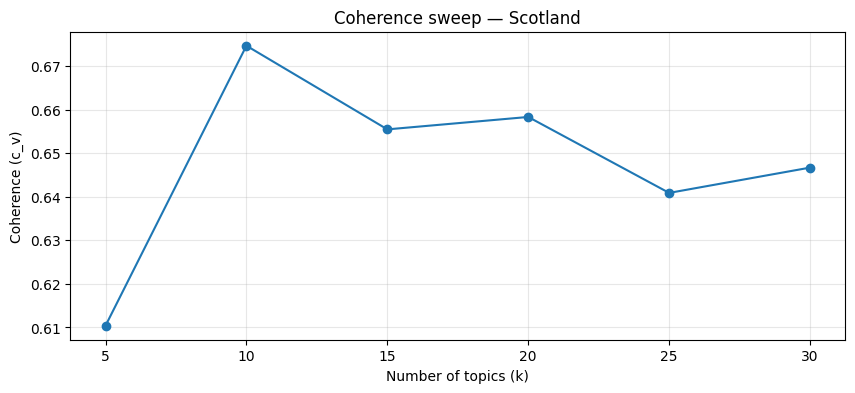


Best k: 10
Choose k based on coherence + interpretability.


In [17]:
from model_pipeline.training.s07_evaluation import evaluate_coherence_over_topic_range
import matplotlib.pyplot as plt

texts_tokens = df_sco["tokens_final"].tolist()

df_coh = evaluate_coherence_over_topic_range(
    X=vec_out.X,
    feature_names=vec_out.feature_names,
    texts_tokens=texts_tokens,
    topic_range=range(5, 35, 5),
    n_top_words=10,
    random_state=42,
    init="nndsvd",
    max_iter=1000,
)

print(df_coh.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(df_coh["n_topics"], df_coh["coherence_cv"], marker="o")
plt.xlabel("Number of topics (k)")
plt.ylabel("Coherence (c_v)")
plt.title("Coherence sweep — Scotland")
plt.grid(True, alpha=0.3)
plt.show()

best_k = list(range(5, 35, 5))[df_coh['coherence_cv'].argmax()]
print(f"\nBest k: {best_k}")
print("Choose k based on coherence + interpretability.")


#### Scotland k=15 chosen over k=10. Coherence peaks at k=10 but domain review shows k=10 produces catch-all topics — notably Topic 2 which blends school meals, attendance statistics, building estate, and literacy into a single theme. At k=15 these separate into interpretable topics. Same rationale as Ireland: coherence alone would select k=10; domain-informed review favours k=15. With 482 articles, k=15 gives ~32 articles per topic.

## 3c. Topic stability across random seeds

In [7]:
seeds = [42, 123, 456, 789, 1024]
H_matrices = []

for seed in seeds:
    model = NMF(n_components=nmf_out.nmf_model.n_components, init="nndsvda", random_state=seed, max_iter=1000)
    model.fit(vec_out.X)
    H_matrices.append(model.components_)
    print(f"Seed {seed}: recon error = {model.reconstruction_err_:.4f}")

pair_scores = []
for i in range(len(seeds)):
    for j in range(i + 1, len(seeds)):
        sim = cosine_similarity(H_matrices[i], H_matrices[j])
        best_matches = sim.max(axis=1).mean()
        pair_scores.append(best_matches)
        print(f"Seeds {seeds[i]} vs {seeds[j]}: avg best-match = {best_matches:.4f}")

avg_stability = np.mean(pair_scores)
print(f"\nOverall topic stability: {avg_stability:.4f}")
print("Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable")


Seed 42: recon error = 19.1934
Seed 123: recon error = 19.2157
Seed 456: recon error = 19.1934
Seed 789: recon error = 19.1934
Seed 1024: recon error = 19.1934
Seeds 42 vs 123: avg best-match = 0.9573
Seeds 42 vs 456: avg best-match = 1.0000
Seeds 42 vs 789: avg best-match = 1.0000
Seeds 42 vs 1024: avg best-match = 1.0000
Seeds 123 vs 456: avg best-match = 0.9582
Seeds 123 vs 789: avg best-match = 0.9582
Seeds 123 vs 1024: avg best-match = 0.9582
Seeds 456 vs 789: avg best-match = 1.0000
Seeds 456 vs 1024: avg best-match = 1.0000
Seeds 789 vs 1024: avg best-match = 1.0000

Overall topic stability: 0.9832
Interpretation: >0.90 = highly stable, 0.80-0.90 = acceptable, <0.80 = unstable


## 4. Raw topic words

In [8]:
topics_sco = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=20)

print(f"{'Topic':>5}  Top 20 Words")
print("=" * 100)
for i, words in enumerate(topics_sco):
    print(f"{i:>5}  {', '.join(words)}")

Topic  Top 20 Words
    0  young, people, young people, child young, youth, work, child, group, community, support, person, prevention, young person, behaviour, service, life, art, advocacy, social, project
    1  teacher, gtc, teaching, standard, profession, registration, professional, fitness, teaching profession, register, education, process, professional standard, strategic, teacher education, council, rule, work, regulation, role
    2  school, pupil, primary, attainment, primary school, library, staff, education, behaviour, support, teacher, estate, book, literacy, school pupil, local, additional, project, attendance, gap
    3  child, family, poverty, child poverty, sector, service, play, government, funding, parent, food, uk, support, child family, payment, charity, life, childcare, policy, time
    4  education, qualification, bill, reform, skill, body, system, national, education reform, learner, assessment, government, inspectorate, change, education bill, inspection, qualif

## 5. Filtered top 30 words

In [9]:
display_stop = {
    "school", "education", "pupil", "student", "teacher", "year", "new", "work",
    "time", "say", "make", "good", "need", "use", "know", "want", "come", "take",
    "people", "government", "report", "system", "support", "include", "provide",
    "number", "change", "part", "set", "high", "low", "level", "national", "local",
    "public", "service", "also", "would", "could", "one", "two", "first", "last",
    "week", "month", "day", "told", "said", "according", "cent", "per", "per cent",
    "child", "children", "young", "staff", "area", "programme", "policy",
    "guidance", "framework", "response", "statement", "proposal", "approach",
    "review", "update", "document", "detail", "section", "datum", "figure",
    "survey", "rate", "score", "point", "proportion", "percentage",
    "organisation", "department", "committee", "institute", "foundation",
    "summit", "voice", "stakeholder", "partnership", "engagement",
    "scheme", "initiative", "pilot", "introduce", "implement", "launch",
    "office", "official", "notification", "recipient", "correspondence",
    "cookie", "banner", "subscribe", "contact", "submit", "accessibility",
    "share", "print", "visit", "site", "experience", "article", "news", "blog",
    "interesting", "fact", "previous", "current", "date", "information",
    "different", "large", "place", "individual", "view", "analysis",
    "thing", "way", "job"
}

topics_full = get_top_words_per_topic(nmf_out.nmf_model, vec_out.feature_names, n_top_words=100)

print(f"{'Topic':>5}  Top 30 Words (display stopwords removed)")
print("=" * 140)
for i, words in enumerate(topics_full):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    print(f"{i:>5}  {', '.join(filtered)}")

Topic  Top 30 Words (display stopwords removed)
    0  young people, child young, youth, group, community, person, prevention, young person, behaviour, life, art, advocacy, social, project, issue, health, opportunity, step, world, lgbtq, activity, creative, harm, impact, member, worker, research, suicide, crime, access
    1  gtc, teaching, standard, profession, registration, professional, fitness, teaching profession, register, process, professional standard, strategic, teacher education, council, rule, regulation, role, registrar, executive registrar, independent, trust, diversity, registration regulation, pauline, dr pauline, pauline stephen, college lecturer, teacher professional, stephen, teacher standard
    2  primary, attainment, primary school, library, behaviour, estate, book, literacy, school pupil, additional, project, attendance, gap, secretary, secondary, additional support, funding, ambassador, inclusion, attainment gap, reading, education secretary, inclusion ambassador

## 5b. Explore a topic — top articles + source concentration

In [10]:
def explore_topic(topic_id, n=5):
    """Show top N articles for a given topic, ranked by topic weight."""
    W = nmf_out.W
    topic_weights = W[:, topic_id]
    top_idx = topic_weights.argsort()[::-1][:n]

    # Topic words
    words = topics_sco[topic_id]
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:20]
    print(f"TOPIC {topic_id} — top words: {', '.join(filtered)}")
    print(f"{'='*120}\n")

    for rank, idx in enumerate(top_idx, 1):
        row = df_sco.iloc[idx]
        weight = topic_weights[idx]
        title = row.get("title", "No title")
        source = row.get("source", "Unknown")
        date = str(row.get("article_date", ""))[:10]
        text = row.get("text_clean", row.get("text", ""))
        if isinstance(text, str) and len(text) > 500:
            text = text[:500] + "..."

        print(f"[{rank}] weight={weight:.4f} | {source} | {date}")
        print(f"    {title}")
        print(f"    {text}\n")

# Source concentration across all topics
print("Source concentration (top 50 articles per topic):")
print("=" * 80)
for t in range(nmf_out.nmf_model.n_components):
    top_idx = nmf_out.W[:, t].argsort()[::-1][:50]
    breakdown = df_sco.iloc[top_idx]['source'].value_counts()
    pct = (breakdown / breakdown.sum() * 100).round(0).astype(int)
    summary = ", ".join(f"{src} {p}%" for src, p in pct.items())
    print(f"Topic {t:>2}: {summary}")




Source concentration (top 50 articles per topic):
Topic  0: children_in_scotland 86%, gov_scot 10%, ades 4%
Topic  1: gtcs 86%, gov_scot 10%, sera 4%
Topic  2: gov_scot 78%, children_in_scotland 20%, ades 2%
Topic  3: children_in_scotland 80%, gov_scot 20%
Topic  4: gov_scot 62%, gtcs 16%, children_in_scotland 12%, ades 8%, sera 2%
Topic  5: children_in_scotland 76%, gov_scot 16%, gtcs 8%
Topic  6: gov_scot 40%, children_in_scotland 30%, ades 18%, gtcs 10%, sera 2%
Topic  7: sera 42%, children_in_scotland 40%, ades 8%, gov_scot 6%, gtcs 4%
Topic  8: children_in_scotland 64%, gov_scot 28%, ades 4%, gtcs 4%
Topic  9: gov_scot 72%, children_in_scotland 18%, ades 4%, gtcs 4%, sera 2%
Topic 10: gtcs 42%, gov_scot 30%, children_in_scotland 20%, sera 4%, ades 4%
Topic 11: gov_scot 86%, ades 6%, children_in_scotland 6%, sera 2%
Topic 12: gov_scot 56%, children_in_scotland 36%, ades 4%, gtcs 4%
Topic 13: gov_scot 50%, children_in_scotland 42%, ades 4%, gtcs 2%, sera 2%
Topic 14: gov_scot 62%, c

In [11]:
explore_topic(14, n=10)


TOPIC 14 — top words: carer, payment, financial, study, package, student support, finance, university, support package, financial support, young carer, international, college, grant, carer support, support payment, funding

[1] weight=0.5025 | gov_scot | 2024-02-19
    Supporting students over the summer
    supporting students over the summer year long financial support for undergraduates higher education students can apply to spread their student financial support package over a month period for the first time this coming academic year the year long package of support will be available for eligible undergraduate students from august the change will ensure that payments of relevant student loans and bursaries can continue through the summer months this follows a successful two year programme which ...

[2] weight=0.4969 | gov_scot | 2023-03-14
    Increased support for students
    increased support for students uplift in bursaries and loan packages financial support available to unde

## 6. LLM-assisted naming

In [12]:
import os
from pathlib import Path
from dotenv import load_dotenv
from anthropic import Anthropic
import json
import re

load_dotenv(Path("../../.env"))
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

topic_keyword_lines = []
for i, words in enumerate(topics_full):
    filtered = [w for w in words if w not in display_stop and len(w) > 2][:30]
    topic_keyword_lines.append(f"Topic {i}: {', '.join(filtered)}")

prompt = f"""You are helping label topics from an NMF topic model trained on Scottish education policy documents (2023-2025).
The corpus includes articles from Scottish Government, Children in Scotland, GTCS, ADES, and SERA.

For each topic below, suggest a short descriptive name (2-4 words, snake_case) based on the keywords, and explain in one sentence why you chose it.

{chr(10).join(topic_keyword_lines)}

Return ONLY a JSON list:
[
  {{"topic": 0, "suggested_name": "name", "explanation": "why"}},
  ...
]
No other text, no markdown, no code fences."""

response = client.messages.create(
    model="claude-sonnet-4-20250514",
    max_tokens=4096,
    messages=[{"role": "user", "content": prompt}],
)

llm_text = response.content[0].text
cleaned = re.sub(r'^```(?:json)?\n?', '', llm_text.strip())
cleaned = re.sub(r'\n?```$', '', cleaned.strip())
llm_results = json.loads(cleaned)

print(f"{'Topic':>5}  {'LLM Suggestion':<35}  Explanation")
print("=" * 120)
for r in llm_results:
    print(f"{r['topic']:>5}  {r['suggested_name']:<35}  {r['explanation']}")

with open("../../data/evaluation_outputs/llm_scotland_topic_review.json", "w") as f:
    json.dump(llm_results, f, indent=2)

INFO:httpx:HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Topic  LLM Suggestion                       Explanation
    0  youth_community_support              This topic focuses on young people's wellbeing through community-based interventions, prevention programs, and advocacy addressing social issues like LGBTQ support and harm reduction.
    1  teaching_profession_regulation       This topic centers on the General Teaching Council's role in maintaining professional standards, registration processes, and regulatory frameworks for the teaching profession.
    2  primary_attainment_equity            This topic addresses efforts to close the attainment gap in primary schools through literacy initiatives, equity funding, and additional support measures.
    3  child_poverty_family                 This topic focuses on addressing child and family poverty through various support mechanisms including child payments, funding, and community-based interventions.
    4  education_reform_qualifications      This topic covers comprehensive education syst

## 7. Finalise Scotland topic names

In [13]:
# Define topic names (k = 15)
SCOTLAND_TOPIC_NAMES = {
    0: "youth_advocacy_and_inclusion",
    1: "teaching_profession_and_regulation",
    2: "attainment_and_school_improvement",
    3: "child_poverty_and_family_support",
    4: "education_reform_and_qualifications",
    5: "childrens_rights_and_uncrc",
    6: "gaelic_language_and_education",
    7: "education_research_networks",
    8: "care_and_the_promise",
    9: "school_leaver_destinations",
    10: "gtcs_digital_services",
    11: "education_statistics",
    12: "free_school_meals_and_poverty",
    13: "breakfast_clubs_and_childcare",
    14: "student_finance_and_carers",
}

# Check for missing topics (expected range = 15)
expected_topics = range(15)
missing = [i for i in expected_topics if i not in SCOTLAND_TOPIC_NAMES]

if missing:
    print(f"WARNING: Missing topic names for: {missing}")
else:
    print("All topics named.")


All topics named.


## 8. Topic distribution by source

In [14]:
df_sco["dominant_topic"] = nmf_out.W.argmax(axis=1)
df_sco["dominant_topic_weight"] = nmf_out.W.max(axis=1)

topic_counts = pd.Series(df_sco["dominant_topic"]).value_counts().sort_index()
print("Topic distribution:")
for t, n in topic_counts.items():
    name = SCOTLAND_TOPIC_NAMES.get(t, f'topic_{t}')
    print(f"  {name}: {n} ({n/len(df_sco)*100:.1f}%)")

print(f"\nDominant weight — mean: {df_sco['dominant_topic_weight'].mean():.4f}")

ct = pd.crosstab(df_sco['source'], df_sco['dominant_topic'], normalize='columns').round(2)
print("\nSource distribution per topic:")
print(ct)

Topic distribution:
  youth_advocacy_and_inclusion: 56 (11.6%)
  teaching_profession_and_regulation: 54 (11.2%)
  attainment_and_school_improvement: 61 (12.7%)
  child_poverty_and_family_support: 83 (17.2%)
  education_reform_and_qualifications: 34 (7.1%)
  childrens_rights_and_uncrc: 20 (4.1%)
  gaelic_language_and_education: 17 (3.5%)
  education_research_networks: 36 (7.5%)
  care_and_the_promise: 24 (5.0%)
  school_leaver_destinations: 11 (2.3%)
  gtcs_digital_services: 19 (3.9%)
  education_statistics: 19 (3.9%)
  free_school_meals_and_poverty: 9 (1.9%)
  breakfast_clubs_and_childcare: 12 (2.5%)
  student_finance_and_carers: 27 (5.6%)

Dominant weight — mean: 0.1936

Source distribution per topic:
dominant_topic          0     1     2     3     4     5     6     7     8   \
source                                                                       
ades                  0.05  0.00  0.05  0.01  0.15  0.00  0.18  0.11  0.00   
children_in_scotland  0.84  0.02  0.26  0.75  0.12  0.

Scotland topic distribution: child poverty largest at 17.2%, reflecting child-centred orientation. Mean dominant weight 0.194. Only 3/15 topics exceed 80% single-source dominance (vs Ireland's 9/15) — most pluralistic discourse of the three countries. Two-actor structure confirmed: children_in_scotland leads advocacy/rights topics, gov_scot leads system/data topics.

## 12. Save model artifacts
**Only run after finalising topic names.**

In [16]:
import joblib
from datetime import datetime

run_id = "sco_" + datetime.now().strftime("%Y-%m-%d_%H%M%S")
run_dir = Path(f"../../experiments/outputs/runs/{run_id}")
run_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(nmf_out.nmf_model, run_dir / "nmf_model.joblib")
joblib.dump(vec_out.vectorizer, run_dir / "vectorizer.joblib")

with open(run_dir / "topic_names.json", "w") as f:
    json.dump(SCOTLAND_TOPIC_NAMES, f, indent=2)

metadata = {
    "run_id": run_id,
    "country": "scotland",
    "n_articles": len(df_sco),
    "n_topics": nmf_out.nmf_model.n_components,
    "reconstruction_error": float(nmf_out.reconstruction_error),
    "topic_stability": float(avg_stability),
    "corpus": "sco_training",
}
with open(run_dir / "run_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved to {run_dir}")
print(f"Contents: {[f.name for f in run_dir.iterdir()]}")


Saved to ../../experiments/outputs/runs/sco_2026-03-23_004346
Contents: ['vectorizer.joblib', 'nmf_model.joblib', 'run_metadata.json', 'topic_names.json']


#### Scotland k=15 final model: 482 articles, 15 topics. Child-centred and rights-based framing dominates — 6 topics have no equivalent in England or Ireland. Most balanced source distribution of the three countries (gov_scot ~40%, children_in_scotland ~35%). Topic stability and source concentration analysis complete. Key cross-jurisdiction finding: Gaelic language emerges as a topic in Scotland but Irish language is absent in Ireland — same policy area, different source selection outcomes.
